# Lattice-encrypted OFDM Simulation using Modular Library
This notebook imports the modular functions from `simulation_library` and executes the full simulation pipeline in a single cell, outputting all requested visualizations and metrics.

In [1]:
%load_ext autoreload
%autoreload 2

# 1. Import libraries
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import sionna
import sionna.phy

# IPython magic function for inline plots
%matplotlib inline

# Import from our modular library
from lattice import LatticeBasedEncryptor, qam16_lattice_to_normalized, qam16_slicer_lattice
from metrics import hadamard_ratio, hadamard_quality, matrix_condition_number, random_unimodular_matrix, generate_lattice_bases
from ber import bit_error_rate, nearest_neighbor_qam_demapper, db_to_linear_amplitude, receiver_amplifier
from plots import plot_constellation, plot_rx_only, plot_signal_snapshot, plot_zoomed_signal, plot_noisy_time_domain

## End-to-End Simulation & Visualizations
Run the cell below to execute the full chain (Data generation -> Mapping -> Encryption -> OFDM modulation -> Attenuating AWGN Channel -> Receiver Amplifier -> Equalized Demodulation -> Linear/Babai decryption -> Hard Demapping) and plot the results.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.



--- FIG 8(a): TRANSMITTED QAM CONSTELLATION ---


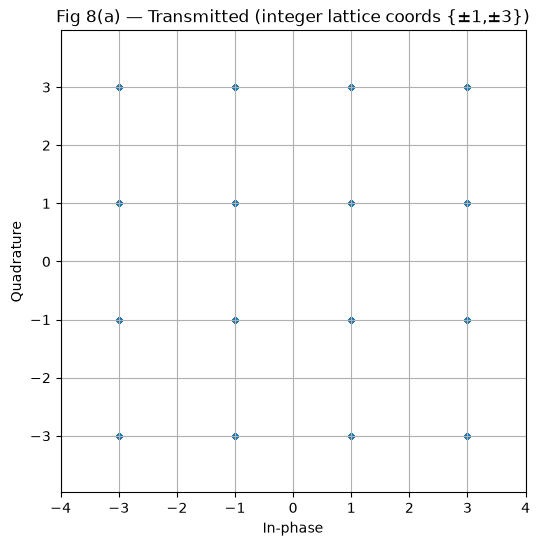

R quality: good  HR(R)=8.3165e-01  rho_R=0.4415
B quality: NOT below badTh  HR(B)=7.6619e-01  rho_B=1.5712
Usable error scale: 3.1823e-01 < sigma < 1.1325e+00
Private basis R shape: (512, 512) | Public basis B shape: (512, 512)
sigma = 1.0192e+00  (window 3.182e-01 .. 1.132e+00)

--- FIG 8(b): ENCRYPTED SIGNAL CONSTELLATION ---


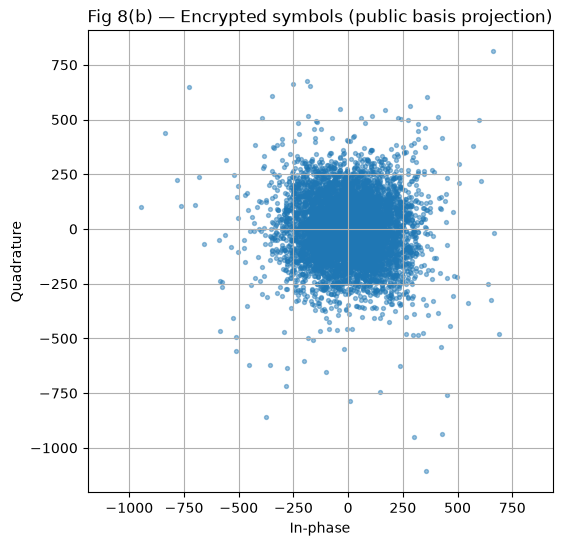


--- TRANSMITTED SIGNAL SNAPSHOT AND ZOOM ---


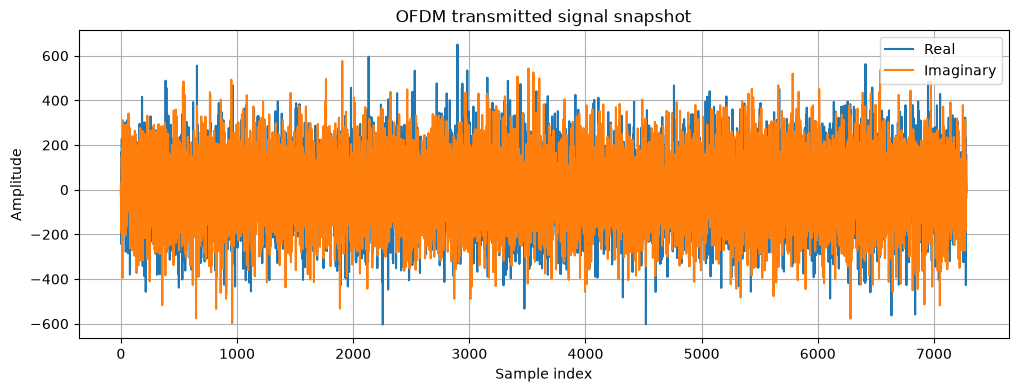

t0: symbol = -6.6792+27.0374j, I = -6.6792, Q = 27.0374
t1: symbol = -25.8944-95.6934j, I = -25.8944, Q = -95.6934
t2: symbol = 51.5248-190.5932j, I = 51.5248, Q = -190.5932
t3: symbol = 154.3637-154.8999j, I = 154.3637, Q = -154.8999


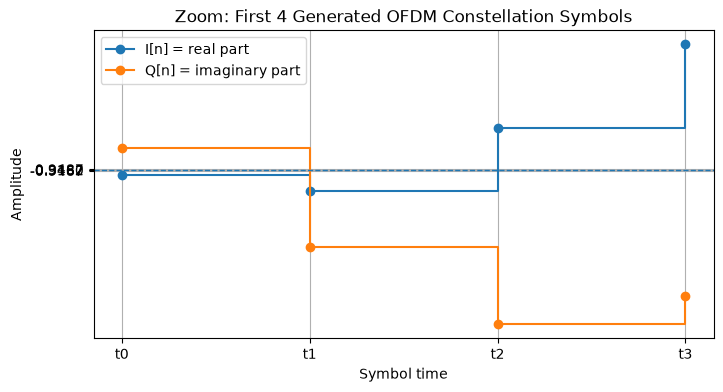

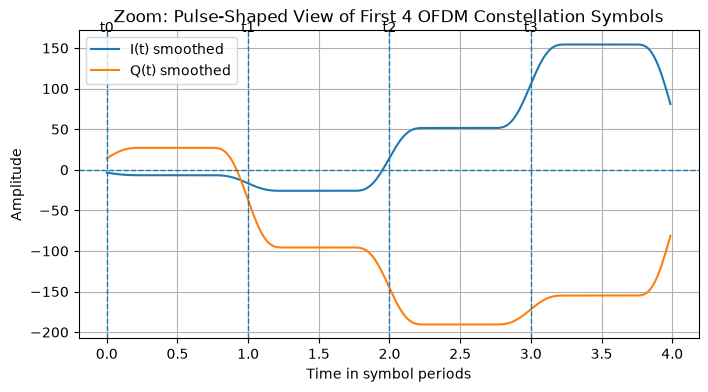


--- NOISY TIME DOMAIN ---


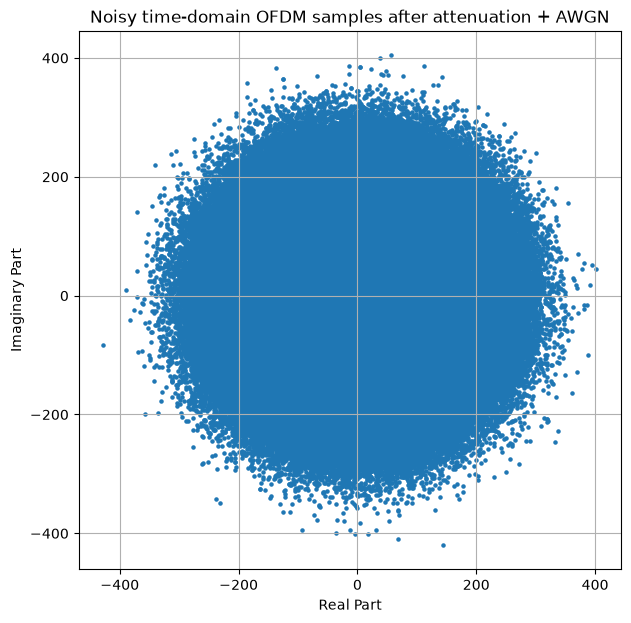

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.



--- FIG 8(c): RECEIVED CONSTELLATION AFTER BABAI (before hard slicer) ---


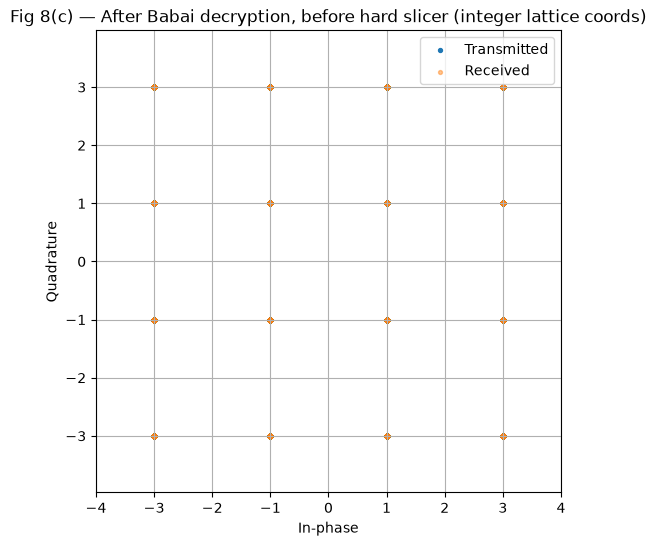


--- RESULTS ---
BER (Babai + hard slicer) at 28 dB:  0.000000e+00


In [2]:
# --- PARAMETERS (Abdallah 2024) ---
batch_size = 1000
num_bits_per_symbol = 4          # 16-QAM -> 4 bits/symbol
fft_size = 512                   # lattice dim = sub-carriers; must be > 350 (Sec. 4.3)
num_ofdm_symbols = 14
cyclic_prefix_length = 8
ebno_db_plot = 15                # Eb/N0 for constellation plot (relative to QAM power)
ebno_db      = 28                # Eb/N0 for BER measurement
channel_attenuation = 0.5
receiver_gain_db = 7.0

# ── 1. Generate bits ──────────────────────────────────────────────────────────
binary_source = sionna.phy.mapping.BinarySource()
bits = binary_source([batch_size, num_ofdm_symbols, fft_size, num_bits_per_symbol])

# ── 2. QAM mapping (Sionna normalised symbols) ────────────────────────────────
constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol)
mapper = sionna.phy.mapping.Mapper(constellation=constellation)
symbols = mapper(bits)           # unit-power, shape [batch, ofdm_syms, fft_size, 1]

# ── 3. Scale to integer lattice coordinates {±1, ±3}  (Fig. 8a) ──────────────
qam_lattice_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float32))
symbols_lattice = symbols.squeeze(-1) * qam_lattice_scale.to(symbols.device)

# Fig 8(a): clean transmitted constellation
print("\n--- FIG 8(a): TRANSMITTED QAM CONSTELLATION ---")
plot_rx_only(symbols_lattice[0], "Fig 8(a) — Transmitted (integer lattice coords {±1,±3})", limit=4)

# ── 4. Lattice encryption  C = B·S + E  (Algorithm 2) ────────────────────────
encryptor = LatticeBasedEncryptor(
    n=fft_size,
    sigma=None,   # auto-selected in window  1/(2*rho_B) < sigma < 1/(2*rho_R)
)
encrypted_symbols = encryptor.encrypt(symbols_lattice)   # complex64

# Fig 8(b): encrypted constellation — noise cloud
print("\n--- FIG 8(b): ENCRYPTED SIGNAL CONSTELLATION ---")
plot_rx_only(encrypted_symbols[0], "Fig 8(b) — Encrypted symbols (public basis projection)")

# ── 5. OFDM modulation: IFFT + cyclic prefix (Eq. 7) ─────────────────────────
ofdm_modulator = sionna.phy.ofdm.OFDMModulator(cyclic_prefix_length=cyclic_prefix_length)
tx_signal = ofdm_modulator(encrypted_symbols.to(torch.complex64))

print("\n--- TRANSMITTED SIGNAL SNAPSHOT AND ZOOM ---")
plot_signal_snapshot(tx_signal)
plot_zoomed_signal(tx_signal, n_symbols=4, samples_per_symbol=80)

# ── 6. AWGN channel ───────────────────────────────────────────────────────────
# Abdallah's SNR axis refers to the received QAM signal, not the encrypted
# signal (which is ~39 dB stronger due to the basis projection). If we use
# Sionna's ebnodb2no directly it normalises against the encrypted power, making
# noise negligible at the receiver. We instead set noise variance relative to
# the mean QAM symbol power so the Eb/N0 axis matches the paper.
qam_power  = (symbols_lattice.abs()**2).mean().item()   # ≈ 10 for 16-QAM {±1,±3}
def noise_var_from_ebno(ebno_db):
    ebno_linear = 10 ** (ebno_db / 10)
    # N0 = E_b / (ebno_linear) = (qam_power / bits_per_symbol) / ebno_linear
    return qam_power / (num_bits_per_symbol * ebno_linear)

tx_signal_attenuated = channel_attenuation * tx_signal
awgn = sionna.phy.channel.AWGN()

# Pass noise_var as tensor (Sionna expects a scalar tensor for no)
rx_signal_plot = awgn(tx_signal_attenuated,
                      torch.tensor(noise_var_from_ebno(ebno_db_plot)))

print("\n--- NOISY TIME DOMAIN ---")
plot_noisy_time_domain(rx_signal_plot)

# ── 7. Receiver: amplify → FFT → equalise ────────────────────────────────────
rx_signal_amp = receiver_amplifier(rx_signal_plot, gain_db=receiver_gain_db)
ofdm_demodulator = sionna.phy.ofdm.OFDMDemodulator(
    fft_size=fft_size,
    cyclic_prefix_length=cyclic_prefix_length,
    l_min=0
)
rx_symbols = ofdm_demodulator(rx_signal_amp)
effective_gain = channel_attenuation * db_to_linear_amplitude(receiver_gain_db)
rx_symbols_equalized = rx_symbols / effective_gain

# ── 8. Babai decryption  Ŝ = B⁻¹ R ⌈R⁻¹ Ĉ⌋  (Algorithm 3) ─────────────────
#
#   received OFDM → FFT → Babai → B⁻¹ → [Fig 8c here] → hard slicer → bits
#
# Plot BEFORE hard slicing, in integer lattice coords {±1,±3}.
# At 15 dB Eb/N0 (relative to QAM power) the noise spread around each of the
# 16 points is clearly visible, matching Abdallah Fig 8(c).
decrypted_lattice_babai = encryptor.decrypt_w_babai(rx_symbols_equalized, use_round=True)

print("\n--- FIG 8(c): RECEIVED CONSTELLATION AFTER BABAI (before hard slicer) ---")
plot_constellation(
    symbols_lattice[0],
    decrypted_lattice_babai[0].to(torch.complex64),
    "Fig 8(c) — After Babai decryption, before hard slicer (integer lattice coords)",
    limit=4
)

# ── 9. BER at ebno_db (separate channel pass) ─────────────────────────────────
rx_signal_ber = awgn(tx_signal_attenuated,
                     torch.tensor(noise_var_from_ebno(ebno_db)))
rx_amp_ber    = receiver_amplifier(rx_signal_ber, gain_db=receiver_gain_db)
rx_sym_ber    = ofdm_demodulator(rx_amp_ber) / effective_gain

decrypted_ber         = encryptor.decrypt_w_babai(rx_sym_ber, use_round=True)
decrypted_sliced      = qam16_slicer_lattice(decrypted_ber)
decrypted_symbols_ber = qam16_lattice_to_normalized(decrypted_sliced)
recovered_bits_babai  = nearest_neighbor_qam_demapper(
    decrypted_symbols_ber, mapper, num_bits_per_symbol
)
ber_babai = bit_error_rate(bits, recovered_bits_babai)

print("\n--- RESULTS ---")
print(f"BER (Babai + hard slicer) at {ebno_db} dB:  {ber_babai:.6e}")


## Point 4 — Lattice dimension > 350
The lattice dimension equals `fft_size` (number of OFDM sub-carriers). Abdallah Sec. 4.3 requires it to exceed 350 (≥400 to resist GGH/NTRU cryptanalysis). `fft_size=512` above satisfies this. Fig. 5 of the paper sweeps N ∈ {32, 64, 128, 256, 512}; only N ≥ 400 is security-relevant.